# ⚙️ Project Overview: Regularization and Robust Pipelines

This exercise tackles a binary classification problem using an opaque dataset, focusing on two advanced ML techniques: **Regularization** (L1 and L2) to combat overfitting, and **Pipelines** for ensuring correct **preprocessing** integration during **Grid Search Cross-Validation (CV)**.

---

## 💾 Ex 1.1: Data Preparation and Baseline Hypothesis

| ML/Data Science Principle | Concept | Goal |
| :--- | :--- | :--- |
| **Data Ingestion & Feature Engineering** | **Target Encoding** | Converting the categorical target classes (`class_1`, `class_2`) into numerical integers (0, 1), which is a requirement for most `scikit-learn` models. |
| **Exploratory Data Analysis (EDA)** | **Visual/Informative Prints** | Performing a preliminary exploration to understand the data's structure (e.g., feature distributions, correlation matrix) and detect potential issues like **class imbalance** or highly skewed features. |
| **Data Splitting** | **Train-Test Protocol (70/30)** | Separating the data ensures that the final model performance is evaluated honestly on data it has never seen, providing a reliable measure of **generalization**. |
| **Model Hypothesis** | **Theoretical Performance Expectation** | Based on the number of features and data size, hypothesizing which classifier (e.g., SVM, Random Forest) is expected to perform best, demonstrating a pre-analysis step. |

---

## 📉 Ex 1.2: Regularization and Feature Selection

This task demonstrates the impact of different regularization terms on model complexity and feature importance.

| ML/Data Science Principle | Concept | Goal |
| :--- | :--- | :--- |
| **Regularization (L1, L2, None)** | **Complexity Control** | Applying three levels of regularization to **Logistic Regression**. The regularization strength **C** (inverse of the penalty strength) is kept constant to isolate the effects of the L1 and L2 norms. |
| **L2 (Ridge) Regularization** | **Shrinkage** | L2 regularization shrinks all coefficients toward zero, resulting in smaller, more stable coefficient magnitudes. It primarily prevents large single coefficients, stabilizing the model against multicollinearity. |
| **L1 (Lasso) Regularization** | **Sparsity / Automatic Feature Selection** | L1 regularization forces some coefficients to become **exactly zero**. The resulting plot will show that the L1 model effectively performs **automatic feature selection**, leaving only the most relevant features with non-zero weights. |
| **Feature Importance Visualization** | **Model Interpretability** | Plotting the coefficient magnitudes visualizes the direct impact of the penalty term on the model's complexity and its reliance on specific features. |

---

## 🎯 Ex 1.3: Robust Hyperparameter Tuning with Pipelines

This is the most critical task, ensuring that the entire ML workflow is encapsulated and optimized correctly.

| ML/Data Science Principle | Concept | Goal |
| :--- | :--- | :--- |
| **Pipelines** | **Robust Workflow** | Integrating the preprocessing step (**Normalization/Standardization**) directly with the classifier. This prevents **data leakage** by ensuring that normalization parameters (mean/std dev) are only calculated from the training fold within each CV iteration. |
| **Grid Search CV** | **Exhaustive Optimization** | Using **GridSearchCV** (instead of RandomizedSearchCV) to systematically explore all combinations of defined hyperparameters across **four diverse classifiers** (RandomForest, SVM, LogisticRegression, kNN). This guarantees finding the global best parameters within the specified grid. |
| **Multi-Model Optimization** | **Model Selection** | The parameter grid is structured as a **list of dictionaries** to accommodate different solvers and penalty terms required by **LogisticRegression** and to search the optimal hyperparameters for different model families. |
| **Final Evaluation** | **Best Model Assessment** | The final model is evaluated on the independent **test set** using **Accuracy** and the **Confusion Matrix** to confirm that the performance gained during the cross-validation process holds true on unseen data. |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCVb
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


/home/erebus/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# ex1.

/tmp/ipykernel_7484/279740710.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['target'] = data['target'].replace({'class_1': 0, 'class_2': 1})


            x_1       x_2       x_3       x_4        x_5       x_6        x_7  \
0     -3.179134 -3.297865  0.657766 -0.421067 -13.240504  4.968418   7.323263   
1     -3.318344 -2.847157 -0.306506 -0.562952  -9.430681  5.970560   9.822562   
2     -4.457964  6.277155 -0.961869 -0.103190  -3.666144 -3.094775   0.150104   
3     -2.509062  8.145651 -0.166136 -0.630612  -2.268176 -6.476636  -0.411657   
4     -4.232712 -2.252182 -0.160233 -0.073965 -11.616706  5.255076   9.505750   
...         ...       ...       ...       ...        ...       ...        ...   
19995 -4.257735 -1.275335  1.289537 -1.820904 -10.601394  4.331989  10.676824   
19996 -2.894255 -2.941663 -0.487484 -2.106600 -10.989896  2.668374   5.746037   
19997 -3.302499 -1.990573 -0.244387  0.535083 -11.848609  5.278285   9.900949   
19998 -4.585303 -4.863886 -0.469507 -0.823398 -12.238430  2.873473   8.722539   
19999 -3.169377 -5.146405  0.235139 -1.311389 -10.459364  3.918006   7.223755   

            x_8       x_9  

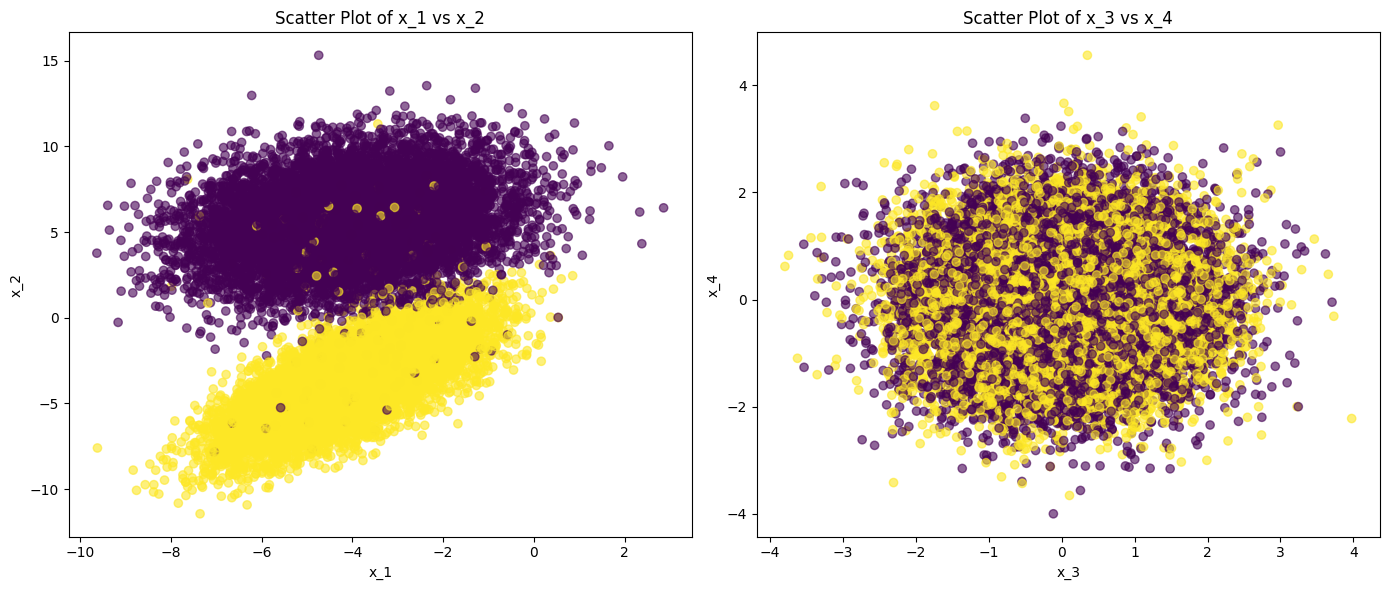

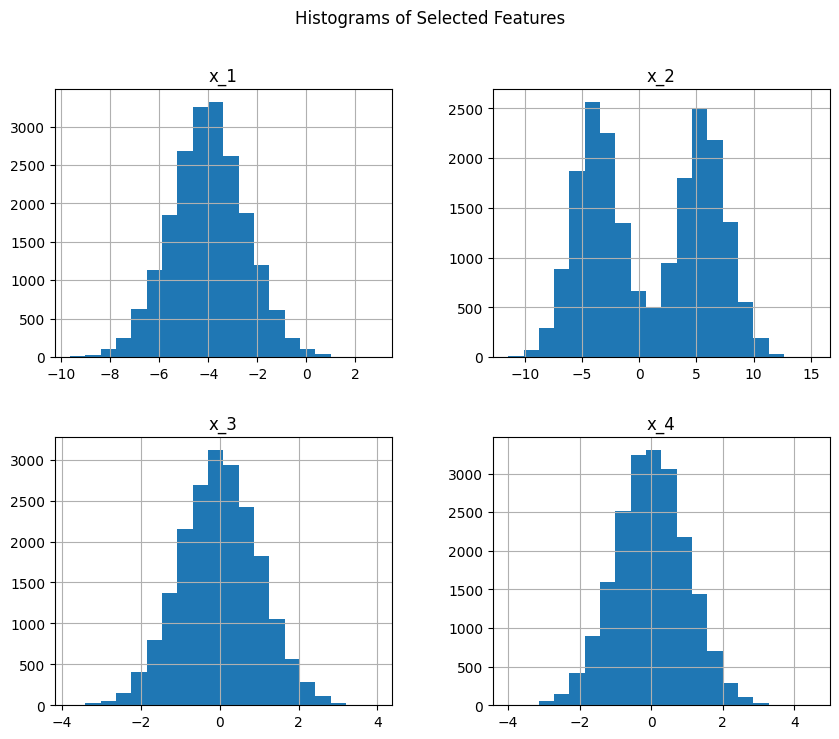

In [2]:
data = pd.read_csv("HW06_data.csv")
data['target'] = data['target'].replace({'class_1': 0, 'class_2': 1}) # replacing the classes with numerical values.
print(data)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].scatter(data['x_1'], data['x_2'], c=data['target'], cmap='viridis', alpha=0.6)
axes[0].set_title("Scatter Plot of x_1 vs x_2")
axes[0].set_xlabel("x_1")
axes[0].set_ylabel("x_2")


axes[1].scatter(data['x_3'], data['x_4'], c=data['target'], cmap='viridis', alpha=0.6)
axes[1].set_title("Scatter Plot of x_3 vs x_4")
axes[1].set_xlabel("x_3")
axes[1].set_ylabel("x_4")


plt.tight_layout()
plt.show()


data[['x_1', 'x_2', 'x_3', 'x_4']].hist(bins=20, figsize=(10, 8))
plt.suptitle("Histograms of Selected Features")
plt.show()


In [3]:

X = data.drop('target', axis=1)  
y = data['target']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 14000 samples
Testing set size: 6000 samples


Prediction: The performance of the Random Forest classifier should exceed that of the other classifiers since it is able to take a large range of feature-target relationships into account

# ex1.2

/home/erebus/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


Accuracy for Logistic Regression (none regularization): 0.9940

Accuracy for Logistic Regression (l1 regularization): 0.9940

Accuracy for Logistic Regression (l2 regularization): 0.9940



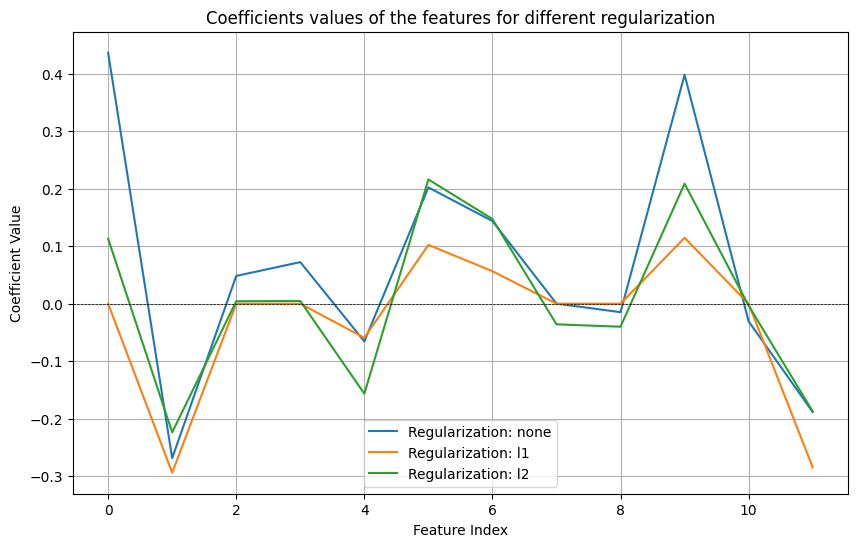

In [4]:
models = {
    'none': LogisticRegression(penalty=None, C=0.001, solver='lbfgs', max_iter=1000),
    'l1': LogisticRegression(penalty='l1', C=0.001, solver='saga', max_iter=1000),
    'l2': LogisticRegression(penalty='l2', C=0.001, solver='lbfgs', max_iter=1000)
}


results = {}
coefficients = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    results[name] = accuracy
    coefficients[name] = model.coef_.flatten() # flattens the coefficients and makes it 1 dimensional.
    print(f"Accuracy for Logistic Regression ({name} regularization): {accuracy:.4f}")
    print()


plt.figure(figsize=(10, 6))
for name, coeffs in coefficients.items():
    plt.plot(range(len(coeffs)), coeffs, label=f'Regularization: {name}')

plt.title("Coefficients values of the features for different regularization")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.show()





- In "none" regularization, the coefficients tend to be of larger magnitude because there is no penalty trying to limit them.
L1 regularization can make some coefficients zero and do feature selection.
• L2 regularization shrinks all coefficients more evenly without allowing sparsity and allows an overall smaller magnitude.

# ex1.3

/home/erebus/.local/lib/python3.10/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(n_estimators=50, random_state=42))])
Test Accuracy: 0.9938


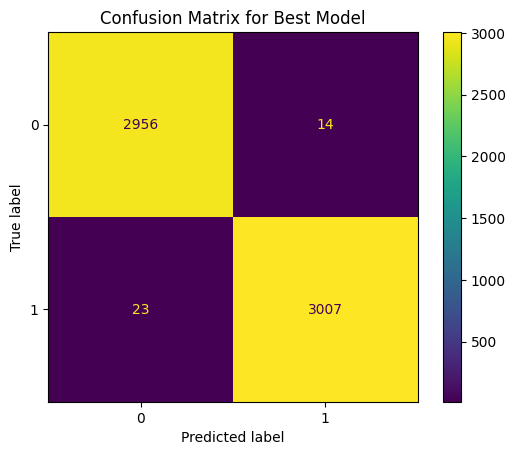

In [5]:
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'SVM': SVC(),
    'LogisticRegression': LogisticRegression(),
    'kNN': KNeighborsClassifier(),
}


param_grid = {
    'RandomForest': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 10, 20],
        'classifier__max_features': ['sqrt', 'log2'], #auto
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
    },
    'SVM': {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf', 'poly'],
    },
    'LogisticRegression': {
        'classifier__C': [0.01, 0.1, 1],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear'],
    },
    'kNN': {
        'classifier__n_neighbors': [3, 5, 7],
        'classifier__metric': ['euclidean', 'manhattan'],
    }
}


pipeline = Pipeline([  
    ('scaler', StandardScaler()), 
    ('classifier', RandomForestClassifier(random_state=42))#placeholder 
])


full_param_grid = []
for model_name, params in param_grid.items():
    model_param = {'classifier': [models[model_name]]}
    model_param.update(params)
    full_param_grid.append(model_param)


grid_search = GridSearchCV(
    pipeline,
    full_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1, # distributing the computational load across the cores of the proccecors for robustness.
)
grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_
test_accuracy = accuracy_score(y_test, best_model.predict(X_test))

print(f"Best Model: {best_model}")
print(f"Test Accuracy: {test_accuracy:.4f}")


ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='viridis')
plt.title("Confusion Matrix for Best Model")
plt.show()